# Macro, market-wide & asset pricing features

## Overview

This notebook retrieves and processes three categories of external features 
that capture broader economic and market conditions. Unlike company-specific 
technical indicators, these features are **market-wide**, they apply equally 
to all three companies (NVDA, AMD, INTC) on any given trading day.

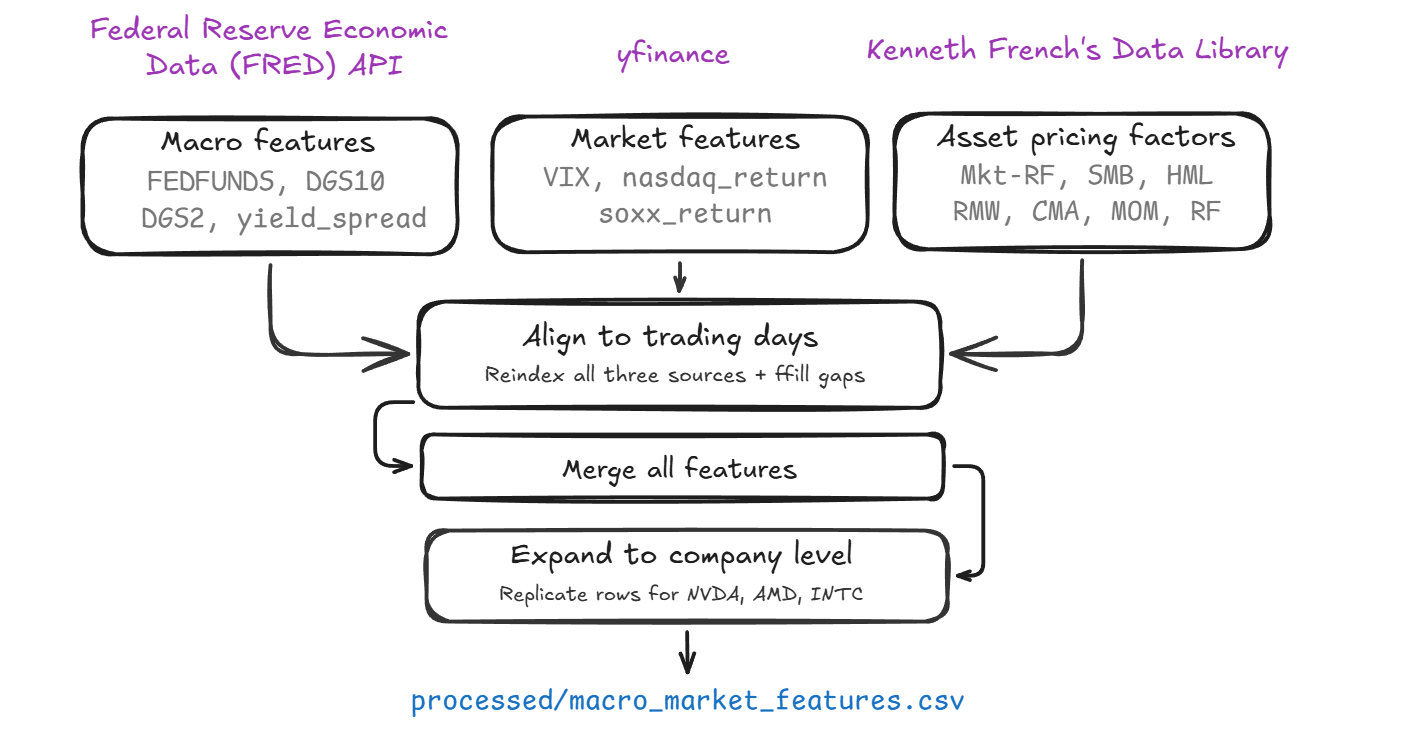

## 1. Configuration

In [1]:
import pandas as pd
import numpy as np
import yfinance as yf
import requests
import warnings
from dotenv import load_dotenv
import os
import matplotlib.pyplot as plt
import seaborn as sns
warnings.filterwarnings('ignore')
load_dotenv()

END_DATE   = '2026-03-28'
COMPANIES  = ['NVDA', 'AMD', 'INTC']

FRED_API_KEY = os.getenv('FRED_API_KEY')

print(f'Companies: {COMPANIES}')

Companies: ['NVDA', 'AMD', 'INTC']


## 2. Data collection and cleaning
This section retrieves three categories of market-wide features from their 
respective sources. All features are later aligned to the trading days 
defined by the Yahoo Finance dataset.

### Macroeconomic Features
Macroeconomic indicators are retrieved from the Federal Reserve Economic 
Data (FRED) API. The following series are collected:

- `FEDFUNDS` — Federal Funds Rate (effective interest rate)
- `DGS10` — 10-Year Treasury yield
- `DGS2` — 2-Year Treasury yield
- `yield_spread` — DGS10 - DGS2 (classic recession indicator)

In [2]:
def fetch_fred_series(series_id, api_key, start, end):
    """
    Fetches a single time series from the FRED API
    and returns it as a pandas Series.
    """
    url = (
        f'https://api.stlouisfed.org/fred/series/observations'
        f'?series_id={series_id}'
        f'&observation_start={start}'
        f'&observation_end={end}'
        f'&api_key={api_key}'
        f'&file_type=json'
    )
    resp = requests.get(url)
    data = resp.json()
    obs  = data['observations']
    df   = pd.DataFrame(obs)[['date', 'value']]
    df['date']  = pd.to_datetime(df['date'])
    df['value'] = pd.to_numeric(df['value'], errors='coerce')
    df = df.set_index('date')['value']
    df.name = series_id
    return df

# start date is changed at the start of month because we get FEDFUNDS value at first day of month
fedfunds = fetch_fred_series('FEDFUNDS', FRED_API_KEY, '2016-03-01', END_DATE)
dgs10    = fetch_fred_series('DGS10',    FRED_API_KEY, '2016-03-01', END_DATE)
dgs2     = fetch_fred_series('DGS2',     FRED_API_KEY, '2016-03-01', END_DATE)

In [3]:
# Merge into DataFrame
macro_df = pd.DataFrame({
    'FEDFUNDS': fedfunds,
    'DGS10':    dgs10,
    'DGS2':     dgs2
})

**Handling missing values**

Since FEDFUNDS is reported monthly and DGS10/DGS2 on business days, 
direct reindexing to trading days would leave gaps where the source date 
does not exist in the trading day index. To resolve this, series are first 
reindexed to all calendar days and forward filled, then reindexed to 
trading days only.

As a result:
- **FEDFUNDS** — same value repeated for all trading days within a month
- **DGS10 / DGS2** — weekends and holidays filled with the last known value
- **yield_spread** — computed after filling, no missing values

In [4]:
# Load trading days from Yahoo Finance
technical_df = pd.read_csv('datasets/processed/yahoo_finance.csv')
technical_df['date'] = pd.to_datetime(technical_df['date'])
trading_days = pd.DatetimeIndex(sorted(technical_df['date'].unique()))

print(f'Trading days: {len(trading_days)}')
print(f'Period: {trading_days.min().date()} to {trading_days.max().date()}')

Trading days: 2471
Period: 2016-05-31 to 2026-03-27


In [5]:
all_days = pd.date_range(
    start=trading_days.min() - pd.Timedelta(days=60),
    end=trading_days.max(),
    freq='D'
)
macro_df = macro_df.reindex(all_days).ffill()

In [6]:
macro_df = macro_df.reindex(trading_days)

In [7]:
# Yield spread
macro_df['yield_spread'] = macro_df['DGS10'] - macro_df['DGS2']

In [8]:
print('\nMissing values after reindex:')
print(macro_df.isna().sum())
print(f'\nShape: {macro_df.shape}')


Missing values after reindex:
FEDFUNDS        0
DGS10           0
DGS2            0
yield_spread    0
dtype: int64

Shape: (2471, 4)


In [9]:
macro_df.head()

,FEDFUNDS,DGS10,DGS2,yield_spread
2016-05-31,0.37,1.84,0.87,0.97
2016-06-01,0.38,1.85,0.91,0.94
2016-06-02,0.38,1.81,0.89,0.92
2016-06-03,0.38,1.71,0.78,0.93
2016-06-06,0.38,1.73,0.80,0.93


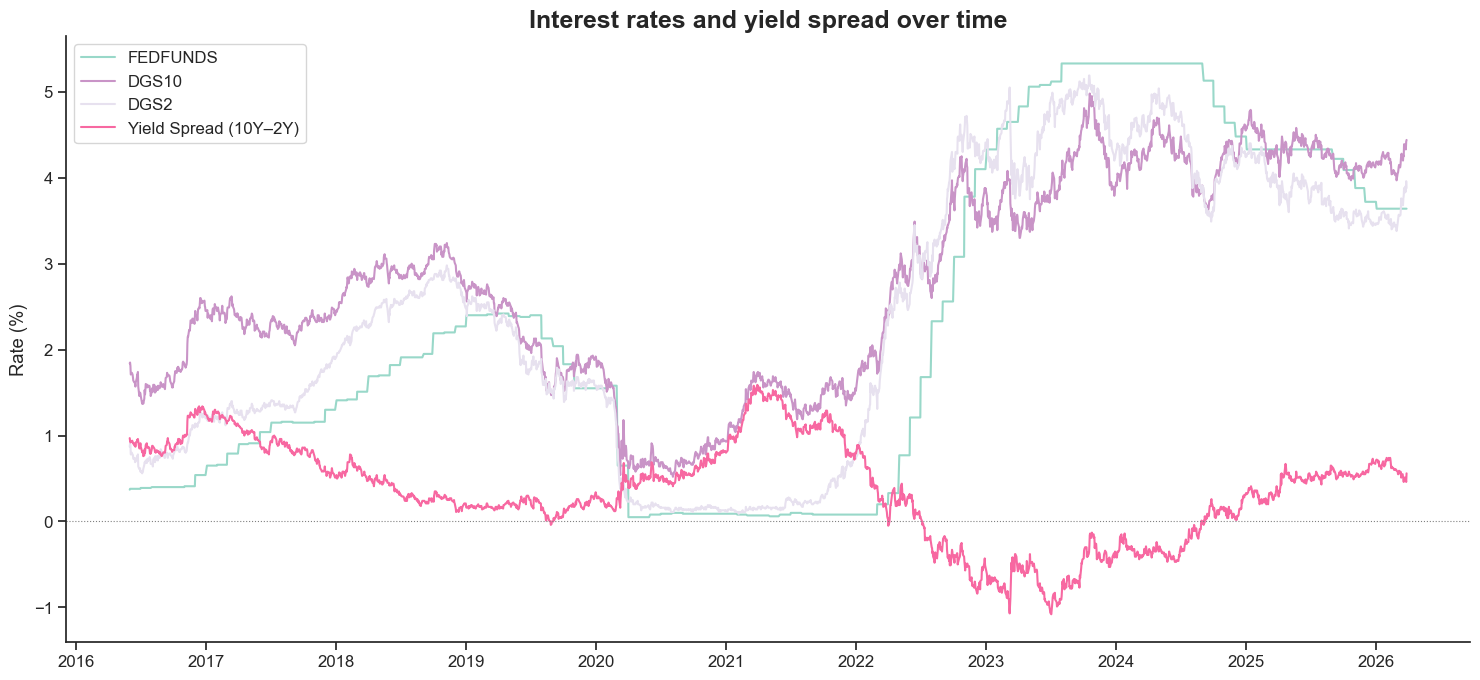

In [10]:
sns.set_theme(style="ticks", font_scale=1.1)

fig, ax = plt.subplots(1, 1, figsize=(15, 7))

ax.plot(macro_df.index, macro_df['FEDFUNDS'], label='FEDFUNDS', color='#99d8c9', linewidth=1.5)
ax.plot(macro_df.index, macro_df['DGS10'],    label='DGS10',    color='#c994c7', linewidth=1.5)
ax.plot(macro_df.index, macro_df['DGS2'],     label='DGS2',     color='#e7e1ef', linewidth=1.5)
ax.plot(macro_df.index, macro_df['yield_spread'], label='Yield Spread (10Y–2Y)', 
        color='#f768a1', linewidth=1.5)
ax.axhline(0, color='gray', linewidth=0.8, linestyle=':')
ax.set_title('Interest rates and yield spread over time', fontsize=18, fontweight='bold')
ax.set_ylabel('Rate (%)')
ax.legend()
sns.despine(ax=ax)
plt.tight_layout()
plt.show()

The chart illustrates the evolution of key interest rate indicators from 2016 to 2026. 
The Federal Funds Rate (FEDFUNDS) remained near zero between 2020 and 2022, reflecting 
the accommodative monetary policy adopted in response to the COVID-19 pandemic, followed 
by an aggressive tightening cycle beginning in 2022, reaching a peak of approximately 
5.3% in 2023. The 10-year (DGS10) and 2-year (DGS2) Treasury yields follow a similar 
pattern, with DGS2 rising faster than DGS10 during the tightening period.

The yield spread (DGS10 − DGS2) turned negative in 2022–2023, indicating a yield curve 
inversion, a historically reliable signal of economic slowdown. The spread subsequently 
recovered toward positive territory by 2024–2025, suggesting a normalization of market 
expectations.

### Market-wide features 
Market-wide indicators capture the overall state of financial markets. We gethered them from ***yfinance*** next features:

- `^VIX` — CBOE Volatility Index
- `^IXIC` — Nasdaq Composite → daily return
- `SOXX` — iShares Semiconductor ETF → daily return

In [11]:
# one day before because percentage change cannot be calculate for the initial observation
START_DATE = '2016-05-27'

market_tickers = ['^VIX', '^IXIC', 'SOXX']
market_raw = yf.download(
    market_tickers,
    start=START_DATE,
    end=END_DATE,
    auto_adjust=True,
    progress=False
)['Close']

market_df = pd.DataFrame()

In [12]:
# VIX — use the raw index value (level, not return)
market_df['VIX'] = market_raw['^VIX']

# Nasdaq and SOXX — use daily returns (%)
market_df['nasdaq_return'] = market_raw['^IXIC'].pct_change() * 100
market_df['soxx_return']   = market_raw['SOXX'].pct_change() * 100

**Handling missing values**

Remove the first row because percentage change cannot be calculated for the initial observation, as there is no previous value to compare with. Since we get data from yfinance, we have only trading days data so it's already compatibile with our previous dataset with stock data.

In [13]:
market_df[market_df.isna().any(axis=1)]

,VIX,nasdaq_return,soxx_return
Date,,,
2016-05-27,13.12,NaN,NaN


In [14]:
market_df = market_df.dropna(how='any')

In [15]:
print('Market-wide features shape:', market_df.shape)

Market-wide features shape: (2471, 3)


In [16]:
market_df.head()

,VIX,nasdaq_return,soxx_return
Date,,,
2016-05-31,14.19,0.294919,0.582527
2016-06-01,14.20,0.084886,0.526470
2016-06-02,13.63,0.385882,0.020963
2016-06-03,13.47,-0.580120,0.293209
2016-06-06,13.65,0.529890,-0.229721


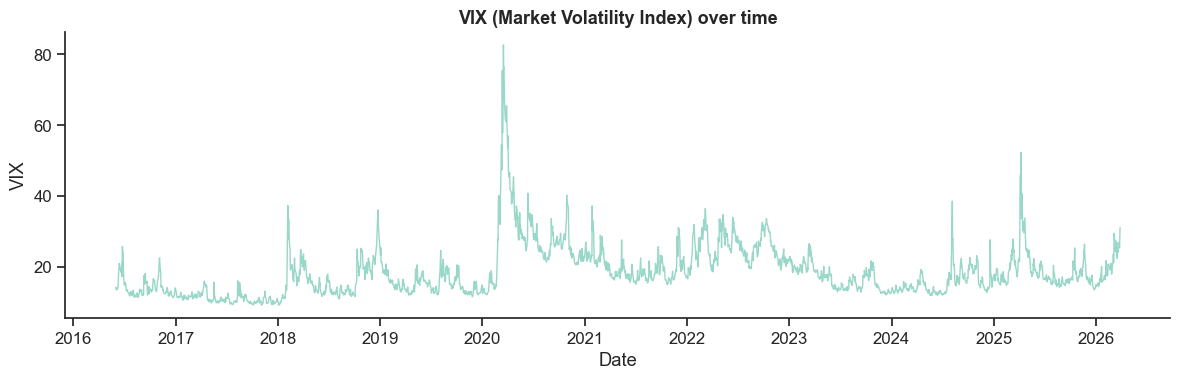

In [17]:
sns.set_theme(style="ticks", font_scale=1.1)

fig, ax = plt.subplots(1, 1, figsize=(12, 4))

ax.plot(market_df.index, market_df['VIX'], color='#99d8c9', linewidth=1)
ax.set_title('VIX (Market Volatility Index) over time', fontsize=13, fontweight='bold')
ax.set_ylabel('VIX')
ax.set_xlabel('Date')
sns.despine(ax=ax)

plt.tight_layout()
plt.show()

The VIX index reflects periods of elevated market uncertainty throughout the observed 
period. The most prominent spike occurred in March 2020, reaching above 80, corresponding 
to the outbreak of the COVID-19 pandemic. Smaller but notable spikes are visible in 
late 2018 (global growth concerns and Fed tightening), 2022 (Russia-Ukraine conflict 
and aggressive rate hikes), and 2025.

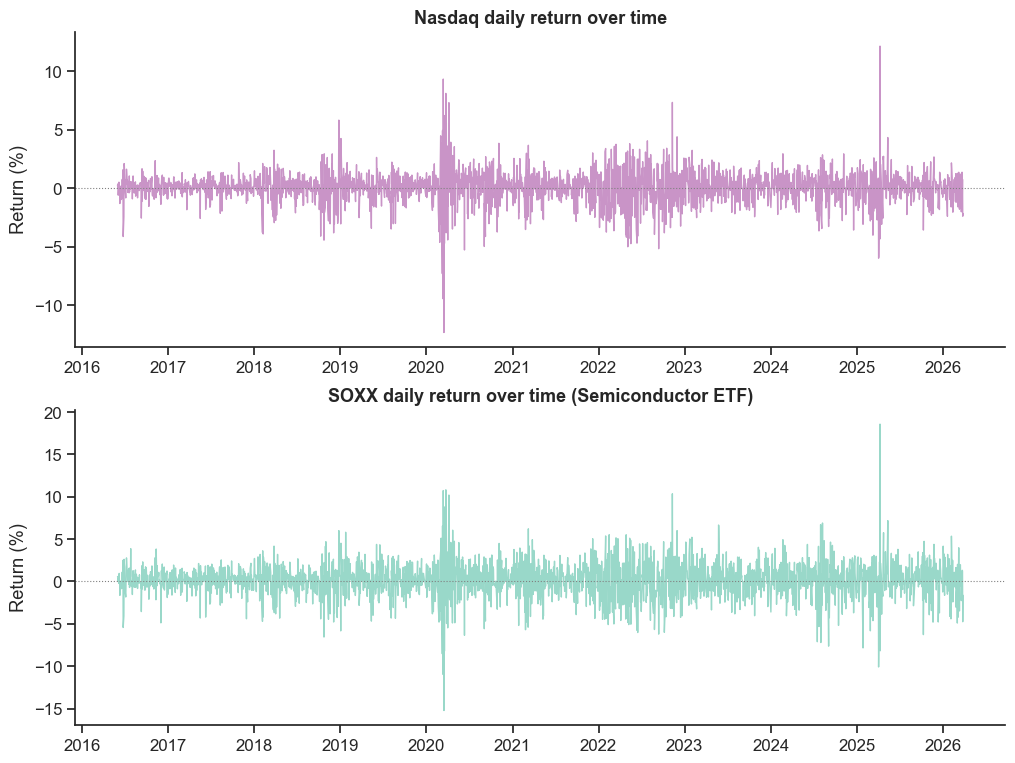

In [18]:
fig, axes = plt.subplots(2, 1, figsize=(12, 9))
ax = axes[0]
ax.plot(market_df.index, market_df['nasdaq_return'], color='#c994c7', linewidth=1)
ax.axhline(0, color='gray', linewidth=0.8, linestyle=':')
ax.set_title('Nasdaq daily return over time', fontsize=13, fontweight='bold')
ax.set_ylabel('Return (%)')
sns.despine(ax=ax)


ax = axes[1]
ax.plot(market_df.index, market_df['soxx_return'], color='#99d8c9', linewidth=1)
ax.axhline(0, color='gray', linewidth=0.8, linestyle=':')
ax.set_title('SOXX daily return over time (Semiconductor ETF)', fontsize=13, fontweight='bold')
ax.set_ylabel('Return (%)')
sns.despine(ax=ax)

plt.show()


The **Nasdaq daily return** fluctuates around zero, with periods of elevated volatility during major market events, most notably the COVID-19 market crash in 2020. This feature captures overall market and technology-sector conditions.

The **SOXX daily return** also fluctuates around zero but exhibits larger swings than the Nasdaq index, reflecting the higher volatility of the semiconductor sector. It serves as an industry-specific indicator for the companies analyzed in this study.

### Fama-French 5 factors + Momentum

Fama-French factors are risk factors retrieved 
directly from Kenneth French's Data Library at Dartmouth. 
The five-factor model (Fama & French, 2015) is extended with the 
Momentum factor:

- `Mkt-RF` — Market risk premium (market return minus risk-free rate)
- `SMB` — Small Minus Big, capturing the size effect
- `HML` — High Minus Low, capturing the value vs. growth effect
- `RMW` — Robust Minus Weak, capturing the profitability effect
- `CMA` — Conservative Minus Aggressive, capturing the investment effect
- `MOM` — Momentum factor, capturing return persistence
- `RF` — Risk-free rate

In [19]:
import pandas_datareader.data as web
START_DATE = '2016-05-31'

def download_fama_french(start: str, end: str) -> pd.DataFrame:
    """
    Download daily Fama-French 5 factors + Momentum from Kenneth 
    French Data Library using pandas_datareader.
    
    Factors:
        Mkt-RF : Market excess return
        SMB    : Small Minus Big (size)
        HML    : High Minus Low (value)
        RMW    : Robust Minus Weak (profitability)
        CMA    : Conservative Minus Aggressive (investment)
        MOM    : Momentum factor
        RF     : Risk-free rate
    """
    # FF5 factors
    ff5 = web.DataReader(
        "F-F_Research_Data_5_Factors_2x3_daily",
        "famafrench",
        start=start,
        end=end
    )[0]

    # Momentum factors
    mom = web.DataReader(
        "F-F_Momentum_Factor_daily",
        "famafrench",
        start=start,
        end=end
    )[0]

    df = ff5.join(mom, how="left")
    df.index = pd.to_datetime(df.index)
    df = df.reset_index().rename(columns={"Date": "date"})
    df["date"] = df["date"].dt.date

    return df


df_ff = download_fama_french(START_DATE, END_DATE)

In [20]:
print('Dataset shape:', df_ff.shape)

Dataset shape: (2471, 8)


In [21]:
# Set date as index before reindexing
df_ff['date'] = pd.to_datetime(df_ff['date'])
df_ff = df_ff.set_index('date')

In [22]:
df_ff.head()

,Mkt-RF,SMB,HML,RMW,CMA,RF,Mom
date,,,,,,,
2016-05-31,-0.01,0.46,-0.37,-0.20,-0.32,0.0,-0.61
2016-06-01,0.20,0.63,-0.21,-0.28,0.06,0.0,-0.03
2016-06-02,0.35,0.26,-0.58,-0.20,-0.04,0.0,-0.60
2016-06-03,-0.38,-0.21,-0.07,0.52,0.14,0.0,0.67
2016-06-06,0.60,0.72,0.31,-0.18,-0.08,0.0,-1.31


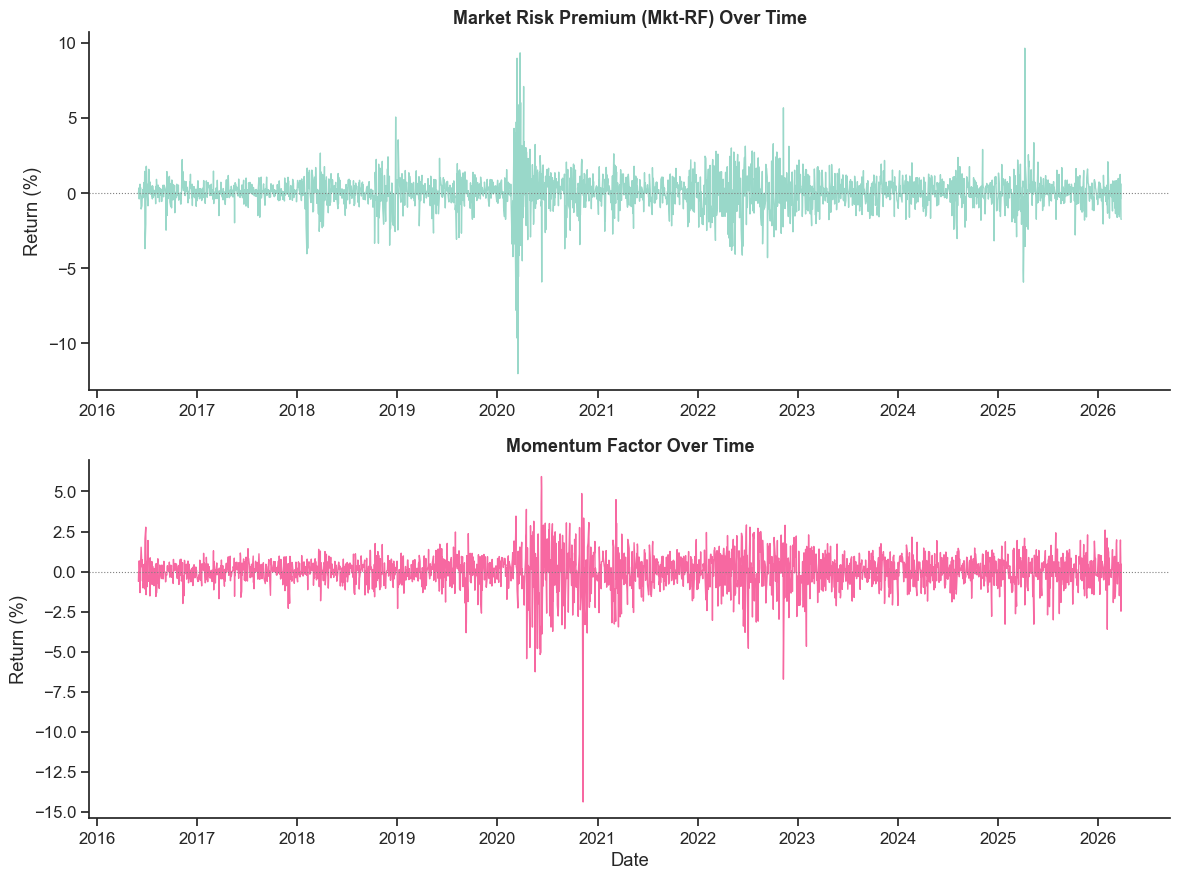

In [23]:
fig, axes = plt.subplots(2, 1, figsize=(12, 9))

ax = axes[0]
ax.plot(df_ff.index, df_ff['Mkt-RF'], color='#99d8c9', linewidth=1)
ax.axhline(0, color='gray', linewidth=0.8, linestyle=':')
ax.set_title('Market Risk Premium (Mkt-RF) Over Time', fontsize=13, fontweight='bold')
ax.set_ylabel('Return (%)')
sns.despine(ax=ax)


ax = axes[1]
ax.plot(df_ff.index, df_ff['Mom'], color='#f768a1', linewidth=1)
ax.axhline(0, color='gray', linewidth=0.8, linestyle=':')
ax.set_title('Momentum Factor Over Time', fontsize=13, fontweight='bold')
ax.set_ylabel('Return (%)')
ax.set_xlabel('Date')
sns.despine(ax=ax)

plt.tight_layout()
plt.show()

Both factors fluctuate around zero and exhibit substantially higher volatility during the COVID-19 market disruption in 2020, indicating their sensitivity to major changes in market conditions and investor behavior.

## 3. Merge features in one dataset

In [24]:
# Merge all features
all_macro_features = pd.concat(
    [macro_df, market_df,df_ff],
    axis=1
)

all_macro_features.index.name = 'date'

print('Final DataFrame shape:', all_macro_features.shape)

print('\nColumns:')
print(all_macro_features.columns.tolist())

Final DataFrame shape: (2471, 14)

Columns:
['FEDFUNDS', 'DGS10', 'DGS2', 'yield_spread', 'VIX', 'nasdaq_return', 'soxx_return', 'Mkt-RF', 'SMB', 'HML', 'RMW', 'CMA', 'RF', 'Mom']


In [25]:
all_macro_features.head()

,FEDFUNDS,DGS10,DGS2,yield_spread,VIX,nasdaq_return,soxx_return,Mkt-RF,SMB,HML,RMW,CMA,RF,Mom
date,,,,,,,,,,,,,,
2016-05-31,0.37,1.84,0.87,0.97,14.19,0.294919,0.582527,-0.01,0.46,-0.37,-0.20,-0.32,0.0,-0.61
2016-06-01,0.38,1.85,0.91,0.94,14.20,0.084886,0.526470,0.20,0.63,-0.21,-0.28,0.06,0.0,-0.03
2016-06-02,0.38,1.81,0.89,0.92,13.63,0.385882,0.020963,0.35,0.26,-0.58,-0.20,-0.04,0.0,-0.60
2016-06-03,0.38,1.71,0.78,0.93,13.47,-0.580120,0.293209,-0.38,-0.21,-0.07,0.52,0.14,0.0,0.67
2016-06-06,0.38,1.73,0.80,0.93,13.65,0.529890,-0.229721,0.60,0.72,0.31,-0.18,-0.08,0.0,-1.31


## 4. Dataset cleaning and conversion to company-level format

Macroeconomic, market-wide, and asset pricing features are identical for all companies (market-level features).

In [26]:
# Verify that no missing values 
print(all_macro_features.isna().sum().sum())

0


In [27]:
shared_cols = [
    'FEDFUNDS', 'DGS10', 'DGS2', 'yield_spread',
    'VIX', 'nasdaq_return', 'soxx_return',
    'Mkt-RF', 'SMB', 'HML', 'RMW', 'CMA', 'RF', 'Mom'
]

rows = []
for company in COMPANIES:
    company_df = all_macro_features[shared_cols].copy()
    company_df['company'] = company
    rows.append(company_df)

final_df = pd.concat(rows).reset_index()
final_df = final_df.rename(columns={'index': 'date'})
final_df = final_df.sort_values(['company', 'date']).reset_index(drop=True)

print('Dataframe shape:', final_df.shape)

Dataframe shape: (7413, 16)


In [28]:
final_df.head()

,date,FEDFUNDS,DGS10,DGS2,yield_spread,VIX,nasdaq_return,soxx_return,Mkt-RF,SMB,HML,RMW,CMA,RF,Mom,company
0,2016-05-31,0.37,1.84,0.87,0.97,14.19,0.294919,0.582527,-0.01,0.46,-0.37,-0.20,-0.32,0.0,-0.61,AMD
1,2016-06-01,0.38,1.85,0.91,0.94,14.20,0.084886,0.526470,0.20,0.63,-0.21,-0.28,0.06,0.0,-0.03,AMD
2,2016-06-02,0.38,1.81,0.89,0.92,13.63,0.385882,0.020963,0.35,0.26,-0.58,-0.20,-0.04,0.0,-0.60,AMD
3,2016-06-03,0.38,1.71,0.78,0.93,13.47,-0.580120,0.293209,-0.38,-0.21,-0.07,0.52,0.14,0.0,0.67,AMD
4,2016-06-06,0.38,1.73,0.80,0.93,13.65,0.529890,-0.229721,0.60,0.72,0.31,-0.18,-0.08,0.0,-1.31,AMD


In [29]:
import os
import mlflow

OUTPUT_DIR = "datasets/processed"
os.makedirs(OUTPUT_DIR, exist_ok=True)

OUTPUT_PATH = f"{OUTPUT_DIR}/macro_market_features.csv"

mlflow.set_tracking_uri("sqlite:///mlflow.db")
mlflow.set_experiment("macro_market_asset_pricing")

with mlflow.start_run(run_name="macro_market_asset_pricing_features"):

    mlflow.log_param("companies", ", ".join(COMPANIES))
    mlflow.log_param("start_date", START_DATE)
    mlflow.log_param("end_date", END_DATE)
    mlflow.log_param("n_features", len(final_df.columns))

    for company in COMPANIES:
        subset = final_df[final_df["company"] == company]
        mlflow.log_metric(f"rows_{company}", len(subset))

    mlflow.log_metric("total_rows", len(final_df))
    mlflow.log_metric("n_companies", final_df["company"].nunique())

    final_df.to_csv(OUTPUT_PATH, index=False)

    print(f"Dataset saved : {OUTPUT_PATH}")
    print("MLflow run    : completed")

2026/06/03 12:06:34 WARNING mlflow.utils.git_utils: Failed to import Git (the Git executable is probably not on your PATH), so Git SHA is not available. Error: Failed to initialize: Bad git executable.
The git executable must be specified in one of the following ways:
    - be included in your $PATH
    - be set via $GIT_PYTHON_GIT_EXECUTABLE
    - explicitly set via git.refresh(<full-path-to-git-executable>)

All git commands will error until this is rectified.

This initial message can be silenced or aggravated in the future by setting the
$GIT_PYTHON_REFRESH environment variable. Use one of the following values:
    - quiet|q|silence|s|silent|none|n|0: for no message or exception
    - warn|w|warning|log|l|1: for a warning message (logging level CRITICAL, displayed by default)
    - error|e|exception|raise|r|2: for a raised exception

Example:
    export GIT_PYTHON_REFRESH=quiet



Dataset saved : datasets/processed/macro_market_features.csv
MLflow run    : completed
